# Front Matter
Here we define everything we need in order to get the model set up

NOte that in addition to the packages you see below, you'll need to install `pytables` to save dataframes to disk.

In [60]:
import json 
import os, shutil
import glob
import numpy as np
import pandas as pd
import flopy
import rasterio as rio
from rasterio import plot as rioplot
from matplotlib import pyplot as plt

#import rasterio as rio
import geopandas as gpd
import rasterio
from rasterio.merge import merge

from rasterio.enums import Resampling
from affine import Affine

## Specify model directories

In [2]:
# Model input files directory
dirInFiles = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers'

# Base model files directory--the actual models will be created in a subdirectory. The 
dirModelFilesBase = r'D:\Users\abolmaal\modelling\Modflow'

# Model executables directory (will be copied to the model base directory for the run)
dirExec = r'D:\Users\abolmaal\modelling\Modflow\helper'

## Define Inputs and Model Properties

In [3]:
# Specify the name of the simulation
nameSim = 'Greatlakes'

# Specify the name of this model 
nameModel = 'Testing'

# Check that names don't exceed the 16 character limit in MODFLOW6
nameModel = '%.16s'%nameModel

# List directories to create, base directory needs to be listed first
dirModelFiles = os.path.join(dirModelFilesBase,nameModel)
createDirs = [dirModelFiles]

# Specify Model Inputs

In [55]:
# Input Rasters
nameInputTop = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\DEM\DEM_merged_3174_30m.tif'
nameInputLayBot = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Bottom\modelbottom.tif'
nameInputIbound = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\extendedBdry_jan26_adk.tif'
nameInputStart = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\domain_water_mask_30m_buff2000m.tif'
nameInputHorizCond = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_multiband.tif'
nameInputVertAni = 'vani'
nameInputRech = 'recharge'

# Specify the extension on the input grid names
extInput = '.tif'

# Inputs specific to the constant head features
pathInputConstHead = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\domain_water_mask_30m_buff2000m.tif'
fieldInputConstHeadElev = 'Elev'

# Inputs specific to the drain features
pathInputDrn = r'F:\Users\kendal30\Modeling\LHM\Prep\2019\Saugatuck\Model_Layers\Groundwater_Teaching\hydro_lines_conn.shp'
fieldInputDrnWidth = 'Width'

# Specify the executable name to use
nameModflowExec = 'mf6.exe'

# Specify model time structural parameters
structure = dict()
structure['name'] = nameModel
structure['perlen'] = [1]
structure['nstp'] = [1]
structure['tsmult'] = [1]
structure['steady'] = [True]

### Specify any other constants used below

In [6]:
# Specify the MODFLOW version string
versionString = 'mf6'

# Specify a nodata value to use
noDataValue = -999

# Specify the conversion factor to get recharge into m/d
rechConv = 1/366 #comes in m/yr

### Output Names

In [7]:
# Model outputs
nameOutInputsStore = 'model_inputs.h5'
nameOutInputsNumpy = 'model_inputs.npz'

## Helper Functions

In [61]:
def read_raster(inFile,nanVal=np.nan):
    # Read in the raster
    with rio.open(inFile) as src:
        inData = src.read()
        inMeta = src.meta

    # Convert NaNs
    inData = np.where(inData == inMeta['nodata'], nanVal, inData)

    return inData 

def get_raster_header(inFile):
    # Read in the raster header
    with rio.open(inFile) as src:
        inMeta = src.meta
        inCRS = src.crs
        inTransform = src.transform
        
    return inMeta, inCRS, inTransform

def get_raster_extent_cellsizes(inMeta):
    # Pull the transform
    transform = inMeta['transform']

    (minX,maxY) = transform * (0,0)
    (maxX,minY) = transform * (inMeta['width'],inMeta['height'])

    cellSizeX = transform[0]
    cellSizeY = -transform[4]
    
    return (minX,maxX,minY,maxY), (cellSizeX,cellSizeY)

def plot_raster(data, transform=None, label=None, title=None, cmap='viridis', \
                ax=None, vmax=None, vmin=None, despine=False):
    # Plot the data
    image = plt.imshow(data, cmap=cmap, vmax=vmax, vmin=vmin)
    rioplot.show(data, transform=transform, cmap=cmap, ax=ax, vmax=vmax, vmin=vmin)

    # Add a title with the name of the colormap
    if title is not None:
        ax.set_title(title)

    # Add the colorbar, scaling it to 50% of the original size
    plt.colorbar(image,ax=ax,shrink=0.5,label=label)

    # Remove spines
    if despine:
        # Remove all the spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        # Remove the ticks and labels
        ax.set_yticks([])
        ax.set_xticks([])

    return

def intersect_grid_feature(objIntsct,pathFeature,lay=0,addFields=[]):
    # Read in the feature
    gdfFeature = gpd.read_file(pathFeature)

    for m in range(0,len(gdfFeature)):
        # Convert the result to a dataframe
        dfResult = pd.DataFrame(objIntsct.intersect(gdfFeature['geometry'][m]))

        # Add in the additional attributes from the original feature
        for thisField in addFields:
            dfResult[thisField] = gdfFeature[thisField][m]

        # Append the layer as the first entry in the cellid tuple, currently has (row,col)
        dfResult['cellids'] = dfResult['cellids'].apply(lambda x: (lay,x[0],x[1]))

        # Make row, col fields
        dfResult['row'] = dfResult['cellids'].apply(lambda x: x[0])
        dfResult['col'] = dfResult['cellids'].apply(lambda x: x[1])

        # Append together
        if m == 0:
            dfIntsct = dfResult.copy()
        else:
            # Append the results, don't use `append`
            dfIntsct = pd.concat([dfIntsct,dfResult],ignore_index=True)
        
    return dfIntsct



def read_raster_preview_multiband(path, max_dim=2000, bands=None, resampling=Resampling.nearest):
    """
    Reads a raster at reduced resolution for preview.
    Returns:
      data: (nbands, out_h, out_w)
      transform: Affine transform for the preview array
      crs: CRS
    """
    with rio.open(path) as src:
        scale = max(src.width / max_dim, src.height / max_dim, 1)
        out_w = int(src.width / scale)
        out_h = int(src.height / scale)

        # Choose bands
        if bands is None:
            # read all bands -> shape (count, out_h, out_w)
            data = src.read(
                out_shape=(src.count, out_h, out_w),
                resampling=resampling
            )
        else:
            # bands should be 1-based list like [1,2,3]
            data = src.read(
                bands,
                out_shape=(len(bands), out_h, out_w),
                resampling=resampling
            )

        # Update transform for the resampled shape
        sx = src.width / out_w
        sy = src.height / out_h
        transform = src.transform * Affine.scale(sx, sy)

        return data, transform, src.crs


## Prepare Environment
This will also create directories if not already done

In [11]:
from pathlib import Path
import flopy

bindir = Path(r"D:\Users\abolmaal\modelling\Modflow\helper")
bindir.mkdir(parents=True, exist_ok=True)

flopy.utils.get_modflow(bindir)  # installs mf6 (+ other related executables)
print("Installed files:", [p.name for p in bindir.iterdir()])

fetched release '23.0' info from MODFLOW-ORG/executables
downloading 'https://github.com/MODFLOW-ORG/executables/releases/download/23.0/win64.zip' to 'C:\Users\abolmaal\Downloads\modflow_executables-23.0-win64.zip'
extracting 25 files to 'D:\Users\abolmaal\modelling\Modflow\helper'
crt.exe (1.3.1)         mfnwt.exe (1.3.0)       sutra.exe (4.0)
gridgen.exe (1.0.02)    mfnwtdbl.exe (1.3.0)    swtv4.exe (4.00.05)
libmf6.dll (6.6.3)      mfusg.exe (1.5)         triangle.exe (1.6)
mf2000.exe (1.19.01)    mfusgdbl.exe (1.5)      vs2dt.exe (3.3)
mf2005.exe (1.12.00)    mfusg_gsi.exe (2.5.0)   zbud6.exe (6.6.3)
mf2005dbl.exe (1.12.00) mp6.exe (6.0.1)         zonbud3.exe (3.01)
mf6.exe (6.6.3)         mp7.exe (7.2.001)       zonbudusg.exe (1.5)
mflgr.exe (2.0.0)       mt3dms.exe (5.3.0)
mflgrdbl.exe (2.0.0)    mt3dusgs.exe (1.1.0)
wrote new flopy metadata file: 'C:\Users\abolmaal\AppData\Local\flopy\get_modflow.json'
Installed files: ['crt.exe', 'gridgen.exe', 'libmf6.dll', 'mf2000.exe', 'mf20

In [12]:
# Prepare the model directories
for thisDir in createDirs:
    if not os.path.exists(thisDir):
        os.mkdir(thisDir)
                
# Copy the MODFLOW executable to the base directory
pathModflowExec = os.path.join(dirModelFiles,nameModflowExec)
shutil.copyfile(os.path.join(dirExec,nameModflowExec),pathModflowExec)

'D:\\Users\\abolmaal\\modelling\\Modflow\\Testing\\mf6.exe'

# Common Model Inputs

## Read in Model Inputs
<div class="alert alert-info">
You can skip this entire section if you are going to import previously prepared inputs, below.
</div>

### Active model area
Creates numpy array `rasterIbound`

In [19]:
# Read in the ibound grid
pathInputIbound = os.path.join(dirInFiles,nameInputIbound)
rasterIbound = read_raster(pathInputIbound)

# Get the header info
header = get_raster_header(pathInputIbound)

# Get the raster extent, returns (minX,maxX,minY,maxY)
extent,cellSizes = get_raster_extent_cellsizes(header[0])

# For convenience, let's define some more structural parameters here
structure['numLay'] = header[0]['count']
structure['numRow'] = header[0]['height']
structure['numCol'] = header[0]['width']
structure['cellSizeX'] = cellSizes[0]
structure['cellSizeY'] = cellSizes[1]
structure['xllCorner'] = extent[0]
structure['yllCorner'] = extent[2]
structure['xulCorner'] = extent[1]
structure['yulCorner'] = extent[3]
structure['EPSG'] = header[0]['crs'].to_epsg()

# Need to replicate the array if it's only a single layer
if rasterIbound.ndim == 2:
    rasterIbound = np.tile(rasterIbound,[structure['numLay'],1,1])

In [21]:
# Specific to my model
# I don't want to have any values of IBOUND == -1 (instead, I am using the CHD package), so I will set those equal to 1
rasterIbound[rasterIbound == -1] = 1

### Create the Structured Grid Object

In [24]:
import numpy as np

nrow = structure["numRow"]
ncol = structure["numCol"]
print("nrow, ncol =", nrow, ncol)
print("cells =", nrow * ncol, " (~", (nrow*ncol)/1e6, "million)")

print("domain width (km)  =", np.sum(delr)/1000)
print("domain height (km) =", np.sum(delc)/1000)
print("cellsize dx,dy (median) =", np.median(delr), np.median(delc))


nrow, ncol = 44167 52728
cells = 2328837576  (~ 2328.837576 million)
domain width (km)  = 1581.84
domain height (km) = 1325.01
cellsize dx,dy (median) = 30.0 30.0


In [26]:
import numpy as np
import flopy

xll = structure["xllCorner"]
yll = structure["yllCorner"]
nlay = structure["numLay"]

width  = float(np.sum(delr))
height = float(np.sum(delc))

dx = 2000.0  # meters
dy = 2000.0  # meters

ncol2 = int(np.ceil(width / dx))
nrow2 = int(np.ceil(height / dy))

delr2 = np.full(ncol2, dx, dtype=float)
delc2 = np.full(nrow2, dy, dtype=float)

grid2 = flopy.discretization.StructuredGrid(
    nlay=nlay, nrow=nrow2, ncol=ncol2,
    delr=delr2, delc=delc2,
    xoff=xll, yoff=yll, angrot=0
)

from flopy.utils.gridintersect import GridIntersect
ix = GridIntersect(grid2)  # should no longer explode memory
# Now create a data frame of our grid cells from the structured grid object
dfGrid = pd.DataFrame(structuredGrid.get_lrc(ix.cellids),columns=['lay','row','col'])

# Create a cellids field with tuples of the layer, row, and column in each row
dfGrid['cellids'] = list(zip(dfGrid['lay'],dfGrid['row'],dfGrid['col']))

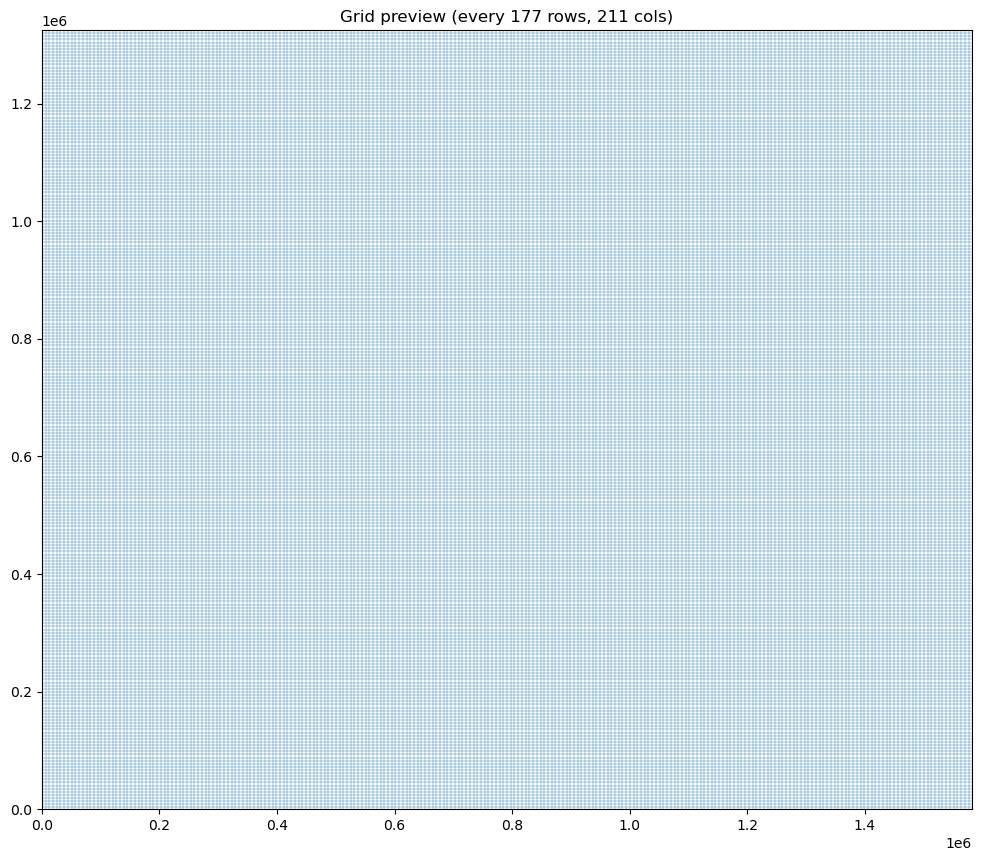

In [28]:
# Visualize it
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def plot_structured_grid_preview(sg, ax=None, max_lines=200, lw=0.4):
    """
    Fast preview plot for HUGE StructuredGrid:
    - avoids sg.xyzvertices / meshgrid
    - plots only every Nth row/col line so it stays light
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    delr = np.asarray(sg.delr, dtype=float)
    delc = np.asarray(sg.delc, dtype=float)

    width  = float(delr.sum())
    height = float(delc.sum())

    # offsets (world coords)
    xoff = float(getattr(sg, "xoff", 0.0))
    yoff = float(getattr(sg, "yoff", 0.0))

    # 1D edges (note: y edges are top->bottom like flopy does internally)
    xedge = xoff + np.r_[0.0, np.cumsum(delr)]
    yedge = yoff + np.r_[height, height - np.cumsum(delc)]

    # decimate lines so we don't draw 100k lines
    step_x = max(1, int(np.ceil(len(xedge) / max_lines)))
    step_y = max(1, int(np.ceil(len(yedge) / max_lines)))

    xs = xedge[::step_x]
    ys = yedge[::step_y]

    xmin, xmax = xedge[0], xedge[-1]
    ymin, ymax = yedge[-1], yedge[0]

    segs = []
    segs += [[(x, ymin), (x, ymax)] for x in xs]     # verticals
    segs += [[(xmin, y), (xmax, y)] for y in ys]     # horizontals

    lc = LineCollection(segs, linewidths=lw)
    ax.add_collection(lc)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f"Grid preview (every {step_y} rows, {step_x} cols)")
    return ax

# use it
fig, ax = plt.subplots(figsize=(12, 12))
plot_structured_grid_preview(structuredGrid, ax=ax, max_lines=250, lw=0.3)
plt.show()


### Model top and layer bottoms
Creates numpy arrays `rasterTop` and `rasterBot`

In [45]:
def read_raster_preview(path, max_dim=2000, band=1):
    with rio.open(path) as src:
        scale = max(src.width / max_dim, src.height / max_dim, 1)
        out_w = int(src.width / scale)
        out_h = int(src.height / scale)
        data = src.read(
            band,
            out_shape=(out_h, out_w),
            resampling=Resampling.nearest
        )
        return data, src.transform

# usage
pathInputTop = os.path.join(dirInFiles, nameInputTop)
top_small, _ = read_raster_preview(pathInputTop, max_dim=1500)

pathInputBot = os.path.join(dirInFiles, nameInputLayBot)
bot_small, _ = read_raster_preview(pathInputBot, max_dim=1500)

In [47]:
# # Here's an alternative to read in separate layer bottom arrays, named nameInputLayBot_<layNum>
# suffixLay = '_lay%d'

# # Loop over the model bottom layers, reading in the raster and then concatenating them along the 0th dimension
# rasterBot = read_raster(os.path.join(dirInFiles,nameInputLayBot+suffixLay%1+extInput))
# for layNum in range(1,structure['numLay']):
#     rasterLay = read_raster(os.path.join(dirInFiles,nameInputLayBot+suffixLay%(layNum+1)+extInput))
#     rasterBot = np.concatenate([rasterBot,rasterLay],axis=0)

# # Or, to be fancy and do it with a list comprehension
# rasterBot = np.concatenate([read_raster(os.path.join(dirInFiles,nameInputLayBot+suffixLay%(layNum+1)+extInput)) for layNum in range(0,structure['numLay'])],axis=0)


### Hydraulic Conductivity
Creates numpy arrays `rasterVani` and `rasterHK`

In [62]:
# Read in hk
pathInputHK = os.path.join(dirInFiles, nameInputHorizCond)
rasterHK, hk_transform, hk_crs = read_raster_preview_multiband(pathInputHK, max_dim=1500)

print(rasterHK.shape)  # -> (3, rows, cols)


(3, 1128, 1500)


#### Adjust HK and VANI values
If you have some reason you want to adjust the HK and VANI values, you can operate on them as shown in the cells below. 

In [ ]:
## Adjust hk 
# Band order: 0=Upper, 1=Mid, 2=Low
# Band order: ['UPKh_m_d', 'MidKh_m_d', 'LowKh_m_d']
rasterHK[0, :, :] = rasterHK[0, :, :] 
rasterHK[1, :, :] = rasterHK[1, :, :] 
rasterHK[2, :, :] = rasterHK[2, :, :] 

### Define vertical anisotropy (VANI) by model layer

This cell creates a 3D `vani` array with the same shape as the multiband hydraulic conductivity raster `rasterHK` (band, row, col).  
`vani` represents the vertical anisotropy ratio **Kh/Kv** (used to estimate vertical hydraulic conductivity from horizontal conductivity).  
A larger VANI means **smaller Kv** relative to Kh.

Assumptions applied here (by depth):
- **Upper layer:** VANI = 10 (Kv = Kh/10)
- **Middle layer:** VANI = 20 (Kv = Kh/20)
- **Lower layer:** VANI = 30 (Kv = Kh/30)

These values impose increasing anisotropy with depth, which is a common conceptual choice for layered sediments.


In [63]:
# Adjust vani
# Logic: usually vertical anisotripy 

vani = np.zeros_like(rasterHK, dtype="float32")
vani[0, :, :] = 10.0
vani[1, :, :] = 20.0
vani[2, :, :] = 30.0

### Starting heads
Creates the `rasterStart` numpy array

In [66]:
import rasterio as rio
with rio.open(pathInputStart) as src:
    print("Raster size:", src.height, src.width, "nodata:", src.nodata, "dtype:", src.dtypes)

print("Model grid:", structure["numRow"], structure["numCol"], "layers:", structure["numLay"])


Raster size: 49758 66126 nodata: 0.0 dtype: ('int16',)


KeyError: 'numRow'

In [65]:

def read_raster_lowmem(path, band=1, nanVal=np.nan, dtype="float32"):
    with rio.open(path) as src:
        data = src.read(band).astype(dtype)   # float32 cuts memory in half vs float64
        nodata = src.nodata
        if nodata is not None:
            # in-place mask (no big np.where copy)
            data[data == nodata] = np.nan if np.isnan(nanVal) else nanVal
        return data

# Read in the starting heads grid
pathInputStart = os.path.join(dirInFiles, nameInputStart)
rasterStart2d = read_raster_lowmem(pathInputStart)

if rasterStart2d.ndim == 2:
    rasterStart = np.tile(rasterStart2d[None, :, :], (structure["numLay"], 1, 1))

MemoryError: Unable to allocate 12.3 GiB for an array with shape (49758, 66126) and data type float32